In [5]:
import glob
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
#import tifffile
import cv2

from skimage.color import label2rgb
import rasterio
from rasterio.enums import ColorInterp

import imageio.v3 as imageio

from tqdm import tqdm

In [14]:
image_filenames = sorted(glob.glob(os.path.join('inference_data/images', "*.tif")))
print(len(image_filenames))

53309


In [15]:
CDL_filenames = []
num_cropland_pixels = []
percent_cropland_pixels = []
for image_filename in tqdm(image_filenames):
    CDL_filename = image_filename.replace("images", "CDL")
    CDL = imageio.imread(CDL_filename)
    CDL_filenames.append(CDL_filename)
    n = np.sum(CDL)
    num_cropland_pixels.append(n)
    percent_cropland_pixels.append(n/(2048*2048))

100%|██████████| 53309/53309 [09:34<00:00, 92.83it/s] 


In [16]:
data = pd.DataFrame({'image_filename': image_filenames, 'CDL_filename': CDL_filenames, 
                     'num_cultivated_pixels':num_cropland_pixels, 'fraction_cultivated_pixels':percent_cropland_pixels})

In [17]:
data

,image_filename,CDL_filename,num_cultivated_pixels,fraction_cultivated_pixels
0,inference_data/images/00001.tif,inference_data/CDL/00001.tif,187845,0.044786
1,inference_data/images/00002.tif,inference_data/CDL/00002.tif,207488,0.049469
2,inference_data/images/00003.tif,inference_data/CDL/00003.tif,156786,0.037381
3,inference_data/images/00004.tif,inference_data/CDL/00004.tif,417042,0.099431
4,inference_data/images/00005.tif,inference_data/CDL/00005.tif,552676,0.131768
...,...,...,...,...
53304,inference_data/images/53375.tif,inference_data/CDL/53375.tif,2815379,0.671239
53305,inference_data/images/53376.tif,inference_data/CDL/53376.tif,2674653,0.637687
53306,inference_data/images/53377.tif,inference_data/CDL/53377.tif,1123789,0.267932
53307,inference_data/images/53378.tif,inference_data/CDL/53378.tif,502586,0.119826


In [24]:
print(len(data[data["fraction_cultivated_pixels"] == 0]) / len(data))

0.016882702733121986


In [22]:
print(len(data[data["fraction_cultivated_pixels"] < 0.01]) / len(data))

0.4338667016826427


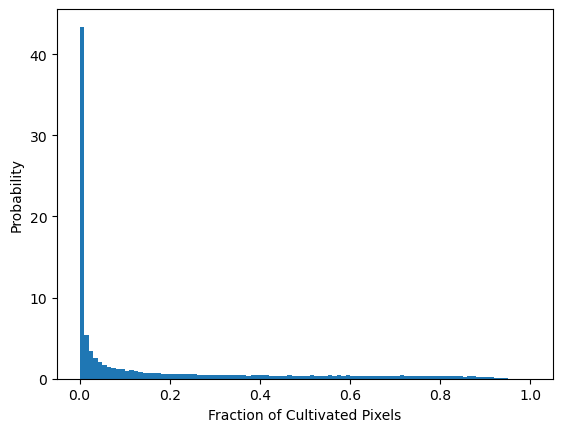

In [23]:
plt.hist(data["fraction_cultivated_pixels"], bins=np.arange(0, 1.01, 0.01), density=True)
plt.xlabel("Fraction of Cultivated Pixels")
plt.ylabel("Probability")
plt.show()

In [25]:
data.to_csv('inference_data/inference_data.csv', index=False)